# Bonus: Neural Network Regression with PyTorch – Auto MPG

## Overview
In this bonus task, we adapt the PyTorch classification notebook from Part 3
to solve the regression problem from Part 1 – predicting fuel efficiency (mpg)
using the Auto MPG dataset.

**Dataset:** Auto MPG – 398 samples, 7 features  
**Target:** mpg (miles per gallon)  
**Framework:** PyTorch with GPU acceleration (CUDA)

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# GPU setup
USE_GPU = True
dtype = torch.float32

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('using device:', device)

# Global style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12
MAIN_COLOR = '#2c7bb6'
SECOND_COLOR = '#d7191c'

using device: cuda


In [22]:
# Reproducibility
import os, random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

## B.1 Dataset and Preprocessing
We load the Auto MPG dataset and apply the same preprocessing as in Part 1:
median imputation for missing horsepower values, StandardScaler normalization,
and a 70/15/15 train/validation/test split. The target variable (mpg) is also
standardized to improve training stability.

In [23]:
import urllib.request

# Load Auto MPG dataset (cached locally for reproducibility)
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)
DATA_PATH = os.path.join(DATA_DIR, "auto-mpg.data")

if not os.path.isfile(DATA_PATH):
    print("Downloading Auto MPG dataset...")
    urllib.request.urlretrieve(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data",
        DATA_PATH
    )

column_names = ['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'model_year', 'origin', 'car_name']

df = pd.read_csv(DATA_PATH, names=column_names, sep=r'\s+', na_values='?')

# Handle missing values
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
feature_cols = ['cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin']
X = df[feature_cols].values
y = df['mpg'].values.reshape(-1, 1)

# Split 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Scale features
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

# Scale target
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_val   = scaler_y.transform(y_val)
y_test  = scaler_y.transform(y_test)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 278 | Val: 60 | Test: 60


## B.2 Architecture and Hyperparameter Search
We define a flexible RegressionNet with configurable hidden size, number of layers,
and dropout rate. We compare 5 configurations using validation RMSE to select
the best hyperparameters. The loss function used is MSE, which is standard for
regression tasks.

In [25]:
# Regression Network
class RegressionNet(nn.Module):
    def __init__(self, hidden_size, num_layers, dropout_rate):
        super().__init__()
        layers = []
        input_size = 7

        for i in range(num_layers):
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 1))
        self.network = nn.Sequential(*layers)

        # Kaiming initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)

    def forward(self, x):
        return self.network(x)

def evaluate(model, loader, scaler_y):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            pred = model(X_batch).cpu().numpy()
            preds.append(pred)
            targets.append(y_batch.cpu().numpy())
    preds = scaler_y.inverse_transform(np.vstack(preds))
    targets = scaler_y.inverse_transform(np.vstack(targets))
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2 = r2_score(targets, preds)
    return rmse, r2

def train_model(hidden_size, num_layers, dropout_rate, lr, epochs=50,
                tr_loader=None, v_loader=None):
    if tr_loader is None: tr_loader = train_loader
    if v_loader is None: v_loader = val_loader
    model = RegressionNet(hidden_size, num_layers, dropout_rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in tr_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = F.mse_loss(pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in v_loader:
                pred = model(X_batch)
                val_loss += F.mse_loss(pred, y_batch).item()

        train_losses.append(epoch_loss / len(tr_loader))
        val_losses.append(val_loss / len(v_loader))

    val_rmse, val_r2 = evaluate(model, v_loader, scaler_y)
    return model, train_losses, val_losses, val_rmse, val_r2

# Hyperparameter search
configs = [
    {'hidden_size': 64,  'num_layers': 2, 'dropout_rate': 0.2, 'lr': 1e-3},
    {'hidden_size': 128, 'num_layers': 2, 'dropout_rate': 0.2, 'lr': 1e-3},
    {'hidden_size': 128, 'num_layers': 3, 'dropout_rate': 0.3, 'lr': 1e-3},
    {'hidden_size': 256, 'num_layers': 3, 'dropout_rate': 0.3, 'lr': 1e-3},
    {'hidden_size': 128, 'num_layers': 2, 'dropout_rate': 0.2, 'lr': 5e-4},
]

print("Hyperparameter Search:")
print(f"{'Config':<40} {'Val RMSE':>10} {'Val R²':>8}")
print("-" * 60)

results = []
for cfg in configs:
    _, _, _, val_rmse, val_r2 = train_model(**cfg)
    label = f"h={cfg['hidden_size']}, l={cfg['num_layers']}, dr={cfg['dropout_rate']}, lr={cfg['lr']}"
    print(f"{label:<40} {val_rmse:>10.3f} {val_r2:>8.3f}")
    results.append((val_rmse, cfg))

best_cfg = min(results, key=lambda x: x[0])[1]
print(f"\nBest config: {best_cfg}")

Hyperparameter Search:
Config                                     Val RMSE   Val R²
------------------------------------------------------------
h=64, l=2, dr=0.2, lr=0.001                   2.411    0.881
h=128, l=2, dr=0.2, lr=0.001                  2.483    0.874
h=128, l=3, dr=0.3, lr=0.001                  2.549    0.868
h=256, l=3, dr=0.3, lr=0.001                  2.448    0.878
h=128, l=2, dr=0.2, lr=0.0005                 2.483    0.874

Best config: {'hidden_size': 64, 'num_layers': 2, 'dropout_rate': 0.2, 'lr': 0.001}


## B.3 Final Model Training
We train the best configuration for 100 epochs and evaluate on the validation
and test sets. We plot the training/validation loss curve and the predicted vs
actual MPG values.

Training final model with best config...
Final Val RMSE: 2.348 | Val R²: 0.888


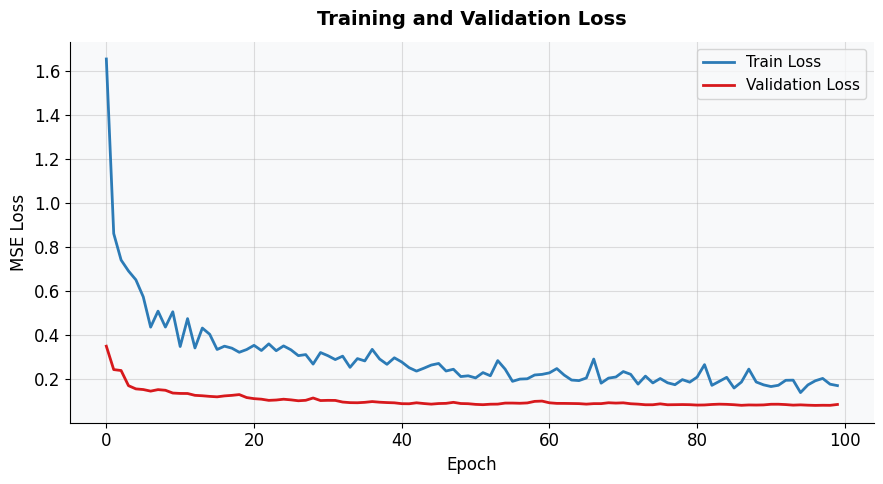

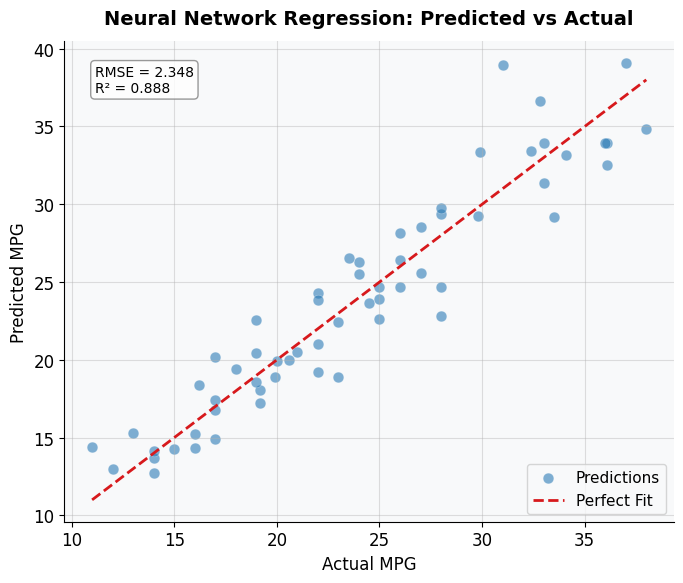


--- Final Model on TEST set ---
RMSE: 2.203
R²:   0.926
Saved checkpoint to: ./checkpoints/mpg_regressor_seed42.pth


In [26]:
# Train final model with best config
print("Training final model with best config...")
best_model, train_losses, val_losses, val_rmse, val_r2 = train_model(**best_cfg, epochs=100)
print(f"Final Val RMSE: {val_rmse:.3f} | Val R²: {val_r2:.3f}")

# Plot 1 - Training and Validation Loss
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_losses, color=MAIN_COLOR, linewidth=2, label='Train Loss')
ax.plot(val_losses, color=SECOND_COLOR, linewidth=2, label='Validation Loss')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_bonus_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 - Predicted vs Actual
best_model.eval()
with torch.no_grad():
    y_val_pred = scaler_y.inverse_transform(
        best_model(X_val_t).cpu().numpy())
y_val_actual = scaler_y.inverse_transform(y_val)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_val_actual, y_val_pred, alpha=0.6, color=MAIN_COLOR,
           edgecolors='white', linewidth=0.3, s=60, label='Predictions')
ax.plot([y_val_actual.min(), y_val_actual.max()],
        [y_val_actual.min(), y_val_actual.max()],
        color=SECOND_COLOR, linestyle='--', linewidth=2, label='Perfect Fit')
ax.set_xlabel('Actual MPG', fontsize=12)
ax.set_ylabel('Predicted MPG', fontsize=12)
ax.set_title('Neural Network Regression: Predicted vs Actual', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11)
textstr = f'RMSE = {val_rmse:.3f}\nR² = {val_r2:.3f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
plt.tight_layout()
plt.savefig('fig_bonus_pred.png', dpi=150, bbox_inches='tight')
plt.show()

# Final evaluation on test set
test_rmse, test_r2 = evaluate(best_model, test_loader, scaler_y)
print(f"\n--- Final Model on TEST set ---")
print(f"RMSE: {test_rmse:.3f}")
print(f"R²:   {test_r2:.3f}")

# Save checkpoint (allows exact reproduction of the reported TEST metrics without retraining)
ckpt_path = os.path.join(CHECKPOINT_DIR, f"mpg_regressor_seed{SEED}.pth")
torch.save({
    "seed": SEED,
    "best_cfg": best_cfg,
    "model_state_dict": best_model.state_dict(),
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
}, ckpt_path)
print(f"Saved checkpoint to: {ckpt_path}")


In [27]:
# (Optional) Quick reproducibility check: load the saved checkpoint and re-evaluate on test
ckpt_path = os.path.join(CHECKPOINT_DIR, f"mpg_regressor_seed{SEED}.pth")
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
reloaded = RegressionNet(
    hidden_size=ckpt["best_cfg"]["hidden_size"],
    num_layers=ckpt["best_cfg"]["num_layers"],
    dropout_rate=ckpt["best_cfg"]["dropout_rate"],
).to(device)

reloaded.load_state_dict(ckpt["model_state_dict"])

test_rmse_reload, test_r2_reload = evaluate(reloaded, test_loader, ckpt["scaler_y"])
print(f"Reloaded checkpoint (seed={ckpt.get('seed')}) -> TEST RMSE: {test_rmse_reload:.3f} | R²: {test_r2_reload:.3f}")

Reloaded checkpoint (seed=42) -> TEST RMSE: 2.203 | R²: 0.926
